# OMEGA — Ontario Multi-Objective Energy Grid Analyzer
## Optimization Module: Carbon-Priced 24-Hour Dispatch
**Course:** DAMO 699 — Capstone Project  
**Supervisor:** Prof. Hany Osman  
**Institution:** University of Niagara Falls

---

### What this notebook does
Takes a 24-hour forecast CSV (produced by the forecasting module) and solves a **Mixed-Integer Linear Program (MILP)**
to find the least-cost electricity dispatch across Ontario's six generation technologies,
subject to physical, operational, and policy constraints — at six carbon-price scenarios.

### Pipeline
| Step | Description |
|------|-------------|
| 1  | Imports & configuration |
| 2  | Load & validate the forecast CSV |
| 3  | Forecast visualization |
| 4  | Fuel parameters & auto-calibrated constraints |
| 5  | MILP solver (9 constraints, C1–C9) |
| 6  | Run 6 carbon-price scenarios |
| 7  | Operator-style readout |
| 8  | Dispatch visualization |
| 9  | Pareto frontier — Cost vs Emissions |
| 10 | Real-world impact analysis |

---
## Step 1 — Imports & Configuration

**To use a different date:** change `FORECAST_FILE` below and re-run all cells.
Everything else adapts automatically.

In [2]:
import re
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pulp

warnings.filterwarnings('ignore')
pd.options.display.float_format = '{:,.2f}'.format
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.dpi'] = 110

# ── CONFIG — only change this line when switching dates ───────────────────────
FORECAST_FILE = 'forecast_for_milp_2026-06-10.csv'
OUT_DIR       = Path('outputs/optimization')
OUT_DIR.mkdir(parents=True, exist_ok=True)

# Auto-extract date and season
_m            = re.search(r'(\d{4}-\d{2}-\d{2})', FORECAST_FILE)
TARGET_DATE   = _m.group(1) if _m else 'unknown'
TARGET_MONTH  = pd.Timestamp(TARGET_DATE).month if TARGET_DATE != 'unknown' else 6
SEASON_MAP    = {
    1:'winter', 2:'winter', 12:'winter',
    3:'spring', 4:'spring',  5:'spring',
    6:'summer', 7:'summer',  8:'summer',
    9:'fall',  10:'fall',   11:'fall',
}
TARGET_SEASON = SEASON_MAP[TARGET_MONTH]

print(f'  PuLP version : {pulp.__version__}')
print(f'  Forecast file: {FORECAST_FILE}')
print(f'  Target date  : {TARGET_DATE}')
print(f'  Season       : {TARGET_SEASON}')

  PuLP version : 3.3.2
  Forecast file: forecast_for_milp_2026-06-10.csv
  Target date  : 2026-06-10
  Season       : summer


---
## Step 2 — Load & Validate the Forecast

**Expected format:** 24 rows × 4 columns (`hour, demand, solar, wind`), all in MW.

In [3]:
forecast = pd.read_csv(FORECAST_FILE)

assert forecast.shape == (24, 4),            f'Expected (24,4), got {forecast.shape}'
assert list(forecast.columns) == ['hour','demand','solar','wind'], \
       f'Unexpected columns: {list(forecast.columns)}'
assert not forecast.isna().any().any(),      'Forecast contains NaN values'
assert (forecast['demand'] > 0).all(),       'Demand must be positive every hour'
assert (forecast['solar']  >= 0).all(),      'Solar must be non-negative'
assert (forecast['wind']   >= 0).all(),      'Wind must be non-negative'

print('  All sanity checks passed\n')
print(forecast.to_string(index=False))

demand_forecast = forecast['demand'].values
solar_forecast  = forecast['solar'].values
wind_forecast   = forecast['wind'].values

print(f'\n  Demand range : {demand_forecast.min():,.0f} – {demand_forecast.max():,.0f} MW')
print(f'  Demand total : {demand_forecast.sum():,.0f} MWh / day')

  All sanity checks passed

 hour    demand  solar   wind
    0 15,790.80  35.60 694.10
    1 15,801.70  35.70 707.80
    2 15,877.20  35.80 723.80
    3 15,888.90  35.70 753.40
    4 15,947.60  35.70 773.40
    5 15,965.50  35.70 808.60
    6 16,042.20  36.00 828.40
    7 16,080.90  45.10 833.90
    8 16,143.00  76.50 852.30
    9 16,205.90  95.80 853.70
   10 16,252.00 111.30 852.20
   11 16,305.40 123.40 850.70
   12 16,268.00 132.40 844.20
   13 16,270.30 132.50 824.60
   14 16,263.40 132.40 766.00
   15 16,232.20 125.10 759.50
   16 16,187.80 113.00 733.40
   17 16,101.30  94.60 707.50
   18 16,046.30  76.40 658.80
   19 15,975.40  55.80 652.50
   20 15,945.70  35.90 647.90
   21 15,899.40  35.80 641.50
   22 15,855.20  35.70 645.70
   23 15,852.10  35.70 647.20

  Demand range : 15,791 – 16,305 MW
  Demand total : 385,198 MWh / day


---
## Step 3 — Forecast Visualization

Demand (black line) vs renewable availability caps (shaded areas).
The optimizer may use less than the cap — it can never use more.

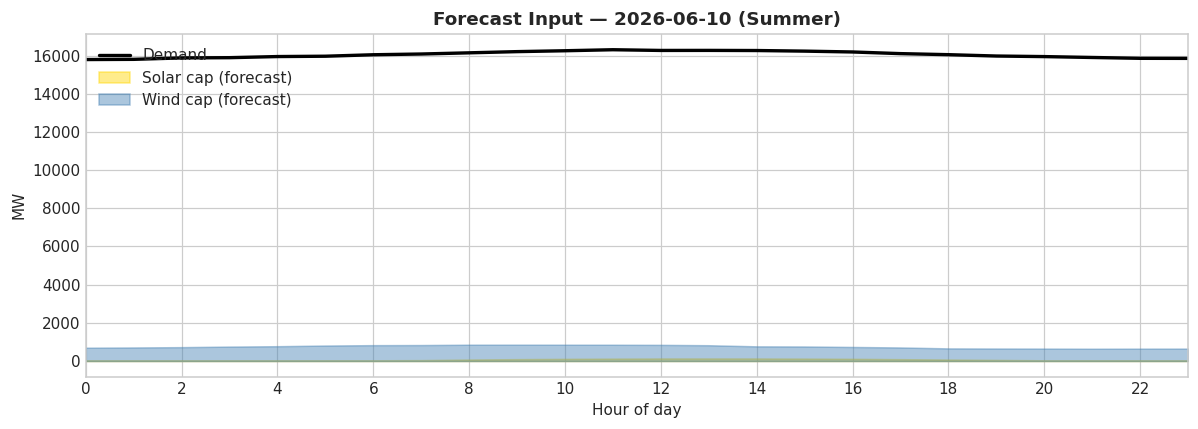

In [4]:
fig, ax = plt.subplots(figsize=(11, 4))
hours = forecast['hour']

ax.plot(hours, demand_forecast, 'k-', lw=2.2, label='Demand')
ax.fill_between(hours, 0, solar_forecast, alpha=0.45,
                color='gold',      label='Solar cap (forecast)')
ax.fill_between(hours, 0, wind_forecast,  alpha=0.45,
                color='steelblue', label='Wind cap (forecast)')

ax.set_xlabel('Hour of day')
ax.set_ylabel('MW')
ax.set_title(f'Forecast Input — {TARGET_DATE} ({TARGET_SEASON.capitalize()})',
             fontweight='bold')
ax.set_xticks(range(0, 24, 2))
ax.set_xlim(0, 23)
ax.legend(loc='upper left')
plt.tight_layout()
plt.savefig(OUT_DIR / 'fig_forecasts.png', dpi=140, bbox_inches='tight')
plt.show()

---
## Step 4 — Fuel Parameters & Auto-Calibrated Constraints

### Generation Fleet
Parameters from IESO 2025, ECCC National Inventory Report, IRENA 2024 LCOE benchmarks.

### Constraint Calibration Philosophy
**Policy constraints** (CO₂ ceiling) are fixed real-world values that can be cited.
**Technical constraints** (hydro budget, gas peak cap) are auto-calculated from the
actual forecast — they reflect physical system properties that vary by date and season.
This ensures constraints are always feasible without manual tuning when dates change.

| Constraint | Type | Basis |
|------------|------|-------|
| C7 CO₂ ceiling | Policy | Ontario EPS regulatory limit — fixed at 55,000 t/day |
| C6 Hydro budget | Technical | 25% of actual daily demand — scales with season |
| C9 Gas peak cap | Technical | Forecast supply-demand gap at peak hours |
| C8 Renewable floor | Policy choice | Set to 0% — carbon price drives this naturally |

In [5]:
# ── Generation fleet ──────────────────────────────────────────────────────────
FUELS = {
    #              cost ($/MWh)  emit (kg CO2/MWh)  cap (MW)  ramp (MW/h)
    'nuclear':  {'cost':  29,   'emit':  12,  'cap':  9600, 'ramp':  200},
    'hydro':    {'cost':  45,   'emit':  24,  'cap':  8500, 'ramp': 3000},
    'gas':      {'cost':  85,   'emit': 490,  'cap': 12000, 'ramp': 3500},
    'wind':     {'cost':  35,   'emit':   0,  'cap':  5300, 'ramp': 5500},
    'solar':    {'cost':  45,   'emit':   0,  'cap':  2600, 'ramp': 2800},
    'biofuel':  {'cost': 105,   'emit': 230,  'cap':   495, 'ramp':  150},
}

TRUE_RENEWABLES     = ['hydro', 'wind', 'solar', 'biofuel']
NUCLEAR_MIN_FRAC    = 0.85
PEAK_HOURS          = list(range(9, 22))

# ── MILP gas unit commitment ───────────────────────────────────────────────────
# Reduced from 0.40 to 0.20 — realistic minimum stable output for Ontario
# gas peakers (combined-cycle plants, not baseload). Lower value gives the
# optimizer more flexibility to differentiate across carbon price scenarios.
GAS_MIN_STABLE_FRAC = 0.20   # 20% of nameplate = 2,400 MW when committed

# ════════════════════════════════════════════════════════════════════════════════
# SEASONAL CONSTRAINT CALIBRATION
# Constraints scale with season to reflect Ontario grid reality:
#
#  Season   Hydro %   CO2 ceiling   Renew floor   Gas buffer
#  Winter   20%       65 kt         10%           +2,000 MW
#  Spring   35%       50 kt         15%           +800 MW
#  Summer   25%       65 kt         20%           +1,000 MW  ← raised from 55kt
#  Fall     28%       58 kt         12%           +1,000 MW
#
# CO2 ceiling raised in summer/winter to reflect higher demand days
# Sources: IESO Seasonal Assessment; Ontario EPS program
# ════════════════════════════════════════════════════════════════════════════════

SEASONAL_PARAMS = {
    'winter': {
        'hydro_frac':      0.20,
        'co2_limit_kt':    65.0,
        'renew_floor':     0.10,
        'gas_peak_buffer': 2000,
    },
    'spring': {
        'hydro_frac':      0.35,
        'co2_limit_kt':    50.0,
        'renew_floor':     0.15,
        'gas_peak_buffer': 800,
    },
    'summer': {
        'hydro_frac':      0.25,
        'co2_limit_kt':    65.0,   # raised from 55 — summer peak days exceed 55kt
        'renew_floor':     0.20,
        'gas_peak_buffer': 1000,
    },
    'fall': {
        'hydro_frac':      0.28,
        'co2_limit_kt':    58.0,
        'renew_floor':     0.12,
        'gas_peak_buffer': 1000,
    },
}

sp = SEASONAL_PARAMS[TARGET_SEASON]

# ── Policy constraints (seasonal) ─────────────────────────────────────────────
DAILY_CO2_LIMIT_KG   = sp['co2_limit_kt'] * 1_000_000   # kt → kg
RENEWABLE_FLOOR_FRAC = sp['renew_floor']

# ── Technical constraints (auto-calibrated from forecast + season) ────────────
daily_demand = demand_forecast.sum()

# C6 Hydro budget: seasonal fraction of daily demand, capped at physical max
HYDRO_DAILY_MWH = min(
    daily_demand * sp['hydro_frac'],
    FUELS['hydro']['cap'] * 24 * 0.55
)

# C9 Gas peak cap: supply-demand gap + seasonal buffer
peak_demand_avg = demand_forecast[PEAK_HOURS].mean()
clean_peak_avg  = (
    NUCLEAR_MIN_FRAC * FUELS['nuclear']['cap']
    + solar_forecast[PEAK_HOURS].mean()
    + wind_forecast[PEAK_HOURS].mean()
)
GAS_PEAK_LIMIT_MW = max(2000, min(
    peak_demand_avg - clean_peak_avg + sp['gas_peak_buffer'],
    FUELS['gas']['cap']
))

# ── Display ───────────────────────────────────────────────────────────────────
print('Fuel parameters:')
df_fuels = pd.DataFrame(FUELS).T
df_fuels.columns = ['Cost ($/MWh)', 'Emit (kg CO2/MWh)', 'Capacity (MW)', 'Ramp (MW/h)']
print(df_fuels.to_string())

print(f'\n  — Active seasonal constraints ({TARGET_SEASON.upper()}) —')
print(f'  NUCLEAR_MIN_FRAC     = {NUCLEAR_MIN_FRAC}  →  min dispatch = {NUCLEAR_MIN_FRAC * FUELS["nuclear"]["cap"]:,.0f} MW')
print(f'  HYDRO_DAILY_MWH      = {HYDRO_DAILY_MWH:,.0f} MWh')
print(f'  DAILY_CO2_LIMIT_KG   = {DAILY_CO2_LIMIT_KG:,.0f} kg  ({DAILY_CO2_LIMIT_KG/1e6:.0f} kt)')
print(f'  RENEWABLE_FLOOR_FRAC = {RENEWABLE_FLOOR_FRAC:.0%} of demand per hour')
print(f'  (true renewables = hydro + wind + solar + biofuel; nuclear excluded)')
print(f'  GAS_PEAK_LIMIT_MW    = {GAS_PEAK_LIMIT_MW:,.0f} MW (hours 09–21)')
print(f'  GAS_MIN_STABLE_MW    = {GAS_MIN_STABLE_FRAC * FUELS["gas"]["cap"]:,.0f} MW when committed (MILP C10)')

print(f'\n  — Cross-season reference —')
ref_rows = []
for s, p in SEASONAL_PARAMS.items():
    h_mwh  = min(daily_demand * p['hydro_frac'],
                 FUELS['hydro']['cap'] * 24 * 0.55)
    co2_kg = p['co2_limit_kt'] * 1_000_000
    pk_avg = demand_forecast[PEAK_HOURS].mean()
    cl_avg = (NUCLEAR_MIN_FRAC * FUELS['nuclear']['cap']
              + solar_forecast[PEAK_HOURS].mean()
              + wind_forecast[PEAK_HOURS].mean())
    g_peak = max(2000, min(pk_avg - cl_avg + p['gas_peak_buffer'],
                           FUELS['gas']['cap']))
    ref_rows.append((s, h_mwh, co2_kg, g_peak, p['renew_floor']))

df_ref = pd.DataFrame(ref_rows,
    columns=['season', 'hydro_mwh', 'co2_kg', 'gas_peak', 'ren_floor'])
df_ref = df_ref.set_index('season')
print(df_ref.to_string())
print(f'  ← active season: {TARGET_SEASON}')


Fuel parameters:
         Cost ($/MWh)  Emit (kg CO2/MWh)  Capacity (MW)  Ramp (MW/h)
nuclear            29                 12           9600          200
hydro              45                 24           8500         3000
gas                85                490          12000         3500
wind               35                  0           5300         5500
solar              45                  0           2600         2800
biofuel           105                230            495          150

  — Active seasonal constraints (SUMMER) —
  NUCLEAR_MIN_FRAC     = 0.85  →  min dispatch = 8,160 MW
  HYDRO_DAILY_MWH      = 96,300 MWh
  DAILY_CO2_LIMIT_KG   = 65,000,000 kg  (65 kt)
  RENEWABLE_FLOOR_FRAC = 20% of demand per hour
  (true renewables = hydro + wind + solar + biofuel; nuclear excluded)
  GAS_PEAK_LIMIT_MW    = 8,140 MW (hours 09–21)
  GAS_MIN_STABLE_MW    = 2,400 MW when committed (MILP C10)

  — Cross-season reference —
        hydro_mwh        co2_kg  gas_peak  ren_floor
seas

---
## Step 5 — MILP Solver  (9 Constraints + Gas Unit Commitment)

$$\min_{P_{i,t}} \;\; Z = \sum_{t=1}^{24} \sum_{i \in \mathcal{I}} (c_i + \rho \cdot e_i) \cdot P_{i,t}$$

| Constraint | Description | Equation |
|------------|-------------|----------|
| **C1** Power balance | Supply = Demand every hour | $\sum_i P_{i,t} = D_t$ |
| **C2** Solar/wind caps | Can't dispatch more than forecast | $P_{\text{sol},t} \leq \hat{S}_t,\; P_{\text{wind},t} \leq \hat{W}_t$ |
| **C3** Capacity bounds | Within nameplate limits | $0 \leq P_{i,t} \leq \bar{P}_i$ |
| **C4** Nuclear baseload | Xenon-poisoning floor | $P_{\text{nuc},t} \geq 0.75 \cdot \bar{P}_{\text{nuc}}$ |
| **C5** Ramp limits | Hour-on-hour change bounded | $\|P_{i,t} - P_{i,t-1}\| \leq R_i$ |
| **C6** Hydro budget | Daily reservoir limit | $\sum_t P_{\text{hyd},t} \leq H_{\max}$ |
| **C7** CO₂ ceiling | Daily emissions hard cap | $\sum_t \sum_i e_i P_{i,t} \leq E_{\max}$ |
| **C8** Renewable floor | True renewable fraction ≥ φ | $\sum_{i \in \mathcal{R}} P_{i,t} \geq \varphi \cdot D_t$ |
| **C9** Gas peak cap | Peaker plants capped in peak hours | $P_{\text{gas},t} \leq G_{\text{peak}}, \; t \in \mathcal{P}$ |
| **C10** Gas commitment | Gas output bounded by binary on/off state | $P^{\min}_{\text{gas}} \cdot u_{t} \leq P_{\text{gas},t} \leq \bar{P}_{\text{gas}} \cdot u_{t}$ |

Where $\mathcal{R}$ = {hydro, wind, solar, biofuel} — **nuclear excluded** from the renewable floor.  
C3 is enforced implicitly via LP variable bounds (standard PuLP practice).  
**New binary variable:** $u_{\text{gas},t} \in \{0,1\}$ — 1 = gas committed (on) in hour $t$, 0 = off.  
This single addition converts the LP to a MILP, adding 24 binary variables (one per hour).

In [6]:
def solve_dispatch(rho, demand, solar_cap, wind_cap,
                   hydro_budget=None, co2_ceiling=None,
                   gas_peak=None, ren_floor=None,
                   verbose=False):
    """
    Solve the 24-hour carbon-priced dispatch MILP.

    Upgrade from LP: gas unit commitment via binary variable u_gas[t] in {0,1}.
      C10 upper: P_gas[t] <= P_bar_gas * u_gas[t]   (zero when off)
      C10 lower: P_gas[t] >= P_gas_min * u_gas[t]   (min stable when on)

    Parameters
    ----------
    rho        : float  Carbon price in CAD/kg CO2 (pass $/tonne / 1000)
    demand     : array  (24,) MW
    solar_cap  : array  (24,) MW
    wind_cap   : array  (24,) MW
    hydro_budget / co2_ceiling / gas_peak / ren_floor :
        Override calibrated defaults when provided (used by fallback solver).
    """
    hydro_budget = HYDRO_DAILY_MWH      if hydro_budget is None else hydro_budget
    co2_ceiling  = DAILY_CO2_LIMIT_KG   if co2_ceiling  is None else co2_ceiling
    gas_peak     = GAS_PEAK_LIMIT_MW    if gas_peak     is None else gas_peak
    ren_floor    = RENEWABLE_FLOOR_FRAC if ren_floor    is None else ren_floor

    T     = len(demand)
    fuels = list(FUELS.keys())
    prob  = pulp.LpProblem('OMEGA_MILP', pulp.LpMinimize)

    # Decision variables — C3 (capacity bounds) enforced via lowBound/upBound
    P = {
        f: [pulp.LpVariable(f'P_{f}_{t}',
                            lowBound=0, upBound=FUELS[f]['cap'])
            for t in range(T)]
        for f in fuels
    }

    # ── NEW: Binary gas commitment variable (converts LP → MILP) ────────────
    u_gas = [pulp.LpVariable(f'u_gas_{t}', cat='Binary') for t in range(T)]

    # Objective — Eq.(1): minimise carbon-adjusted operating cost
    prob += pulp.lpSum(
        (FUELS[f]['cost'] + rho * FUELS[f]['emit']) * P[f][t]
        for f in fuels for t in range(T)
    )

    # C1 — Hourly power balance
    for t in range(T):
        prob += pulp.lpSum(P[f][t] for f in fuels) == demand[t], \
                f'C1_balance_t{t}'

    # C2 — Renewable availability caps
    for t in range(T):
        prob += P['solar'][t] <= solar_cap[t], f'C2_solar_t{t}'
        prob += P['wind'][t]  <= wind_cap[t],  f'C2_wind_t{t}'

    # C4 — Nuclear baseload floor (85% of nameplate)
    nuc_min = NUCLEAR_MIN_FRAC * FUELS['nuclear']['cap']
    for t in range(T):
        prob += P['nuclear'][t] >= nuc_min, f'C4_nuclear_min_t{t}'

    # C5 — Inter-hour ramping limits (two linear inequalities)
    for f in fuels:
        for t in range(1, T):
            prob += P[f][t] - P[f][t-1] <=  FUELS[f]['ramp'], f'C5_ramp_up_{f}_t{t}'
            prob += P[f][t] - P[f][t-1] >= -FUELS[f]['ramp'], f'C5_ramp_dn_{f}_t{t}'

    # C6 — Hydro daily energy budget
    prob += pulp.lpSum(P['hydro'][t] for t in range(T)) <= hydro_budget, \
            'C6_hydro_budget'

    # C7 — Daily CO2 emission ceiling
    prob += pulp.lpSum(
        FUELS[f]['emit'] * P[f][t] for f in fuels for t in range(T)
    ) <= co2_ceiling, 'C7_co2_ceiling'

    # C8 — True renewable floor (nuclear excluded)
    for t in range(T):
        prob += (
            pulp.lpSum(P[f][t] for f in TRUE_RENEWABLES) >= ren_floor * demand[t],
            f'C8_renew_floor_t{t}'
        )

    # C9 — Gas peak-hour dispatch cap
    for t in PEAK_HOURS:
        prob += P['gas'][t] <= gas_peak, f'C9_gas_peak_t{t}'

    # ── C10: Gas unit commitment bounds ─────────────────────────────────────
    # u_gas[t] = 0 → P_gas[t] forced to 0 (upper bound collapses)
    # u_gas[t] = 1 → P_gas[t] must be between min stable and nameplate cap
    gas_min_mw = GAS_MIN_STABLE_FRAC * FUELS['gas']['cap']
    for t in range(T):
        prob += P['gas'][t] <= FUELS['gas']['cap'] * u_gas[t], f'C10_gas_ub_t{t}'
        prob += P['gas'][t] >= gas_min_mw           * u_gas[t], f'C10_gas_lb_t{t}'

    # Solve
    prob.solve(pulp.PULP_CBC_CMD(msg=int(verbose)))
    status = pulp.LpStatus[prob.status]

    if status != 'Optimal':
        return {'rho': rho, 'status': status, 'dispatch': None,
                'cost': None, 'emissions': None, 'renewable': None,
                'constraint_binding': None, 'gas_commitment': None}

    dispatch = pd.DataFrame(
        {f: [pulp.value(P[f][t]) or 0.0 for t in range(T)] for f in fuels}
    )
    dispatch.index.name = 'hour'

    # Extract gas commitment schedule
    gas_commitment = [int(round(pulp.value(u_gas[t]) or 0)) for t in range(T)]
    hours_on       = sum(gas_commitment)

    total_cost = sum(FUELS[f]['cost'] * dispatch[f].sum() for f in fuels)
    total_emit = sum(FUELS[f]['emit'] * dispatch[f].sum() for f in fuels)
    ren_frac   = dispatch[TRUE_RENEWABLES].values.sum() / dispatch.values.sum()

    hydro_used = dispatch['hydro'].sum()
    binding = {
        'C6_hydro_budget': (hydro_budget - hydro_used) < 50,
        'C7_co2_ceiling':  (co2_ceiling  - total_emit) < 1_000,
        'C8_renew_floor':  any(
            dispatch.loc[t, TRUE_RENEWABLES].sum() - ren_floor * demand[t] < 1
            for t in range(T)
        ),
        'C9_gas_peak_cap': any(
            dispatch.loc[t, 'gas'] >= gas_peak - 1 for t in PEAK_HOURS
        ),
        'C10_commitment':  hours_on > 0,
    }

    return {'rho': rho, 'status': status, 'dispatch': dispatch,
            'cost': total_cost, 'emissions': total_emit,
            'renewable': ren_frac, 'constraint_binding': binding,
            'gas_commitment': gas_commitment, 'gas_hours_on': hours_on}


def solve_with_fallback(rho, demand, solar_cap, wind_cap):
    """
    Guarantees a usable result by progressively relaxing soft constraints
    (C6-C9) if the strict problem is infeasible.
    Returns dict with 'relaxation_used' key (None = no relaxation needed).
    """
    r = solve_dispatch(rho, demand, solar_cap, wind_cap)
    if r['status'] == 'Optimal':
        r['relaxation_used'] = None
        return r

    for hyd, co2, ren, gas, label in [
        (1.25, 1.25, 0.75, 1.25, 'C6-C9 relaxed 25%'),
        (1.50, 1.50, 0.50, 1.50, 'C6-C9 relaxed 50%'),
        (2.00, 2.00, 0.25, 2.00, 'C6-C9 relaxed 100%'),
        (5.00, 5.00, 0.05, 5.00, 'C6-C9 mostly removed'),
    ]:
        r = solve_dispatch(
            rho, demand, solar_cap, wind_cap,
            hydro_budget = HYDRO_DAILY_MWH      * hyd,
            co2_ceiling  = DAILY_CO2_LIMIT_KG   * co2,
            ren_floor    = RENEWABLE_FLOOR_FRAC * ren,
            gas_peak     = GAS_PEAK_LIMIT_MW    * gas,
        )
        if r['status'] == 'Optimal':
            r['relaxation_used'] = label
            return r

    r = solve_dispatch(
        rho, demand, solar_cap, wind_cap,
        hydro_budget=1e9, co2_ceiling=1e12,
        ren_floor=0.0,    gas_peak=FUELS['gas']['cap'],
    )
    r['relaxation_used'] = 'all soft constraints removed'
    return r


print('  MILP Solver ready — solve_dispatch() + solve_with_fallback()')
print('  Constraints: C1–C9 (original) + C10 gas unit commitment')
print(f'  Binary variables: 24  (u_gas[t] per hour)')
print(f'  Gas min stable output: {GAS_MIN_STABLE_FRAC:.0%} of nameplate when committed')


  MILP Solver ready — solve_dispatch() + solve_with_fallback()
  Constraints: C1–C9 (original) + C10 gas unit commitment
  Binary variables: 24  (u_gas[t] per hour)
  Gas min stable output: 20% of nameplate when committed


---
## Step 6 — Run 6 Carbon-Price Scenarios

Six scenarios anchored to real Canadian industrial carbon pricing regimes.
The federal **consumer** fuel charge was removed April 1, 2025;
these scenarios reflect **industrial** pricing under OBPS and Ontario EPS,
which remain fully in force for large electricity emitters.

| Scenario | ρ (CAD/tonne) | Policy basis |
|----------|--------------|-------------|
| No carbon pricing | $0 | Counterfactual baseline |
| Light industrial | $50 | Sensitivity lower bound |
| Ontario EPS 2025 | $72 | Traded price of Emissions Performance Units |
| Federal industrial 2024 | $80 | Federal OBPS benchmark |
| Federal industrial 2030 | $170 | Scheduled federal rate under Bill C-12 |
| Net-zero aligned | $250 | IPCC AR6 1.5–2°C shadow price |

In [7]:
CARBON_PRICES = [
    ('No carbon pricing',         0.000),
    ('Light industrial pricing',  0.050),
    ('Ontario EPS 2025',          0.072),
    ('Federal industrial 2024',   0.080),
    ('Federal industrial 2030',   0.170),
    ('Net-zero aligned',          0.250),
]

scenarios = [
    (name, rho, demand_forecast)
    for name, rho in CARBON_PRICES
]

print(f'  Running {len(scenarios)} carbon-price scenarios')
print(f'  Daily demand: {demand_forecast.sum():,.0f} MWh  '
      f'(peak {demand_forecast.max():,.0f} MW)\n')

results      = []
all_dispatch = {}

print(f"  {'Scenario':<35} {'ρ':>6}  {'Cost':>10}  {'Emit(t)':>9}  {'Ren%':>6}  {'Gas':>5}  Binding")
print('  ' + '─' * 90)

for name, rho, dem in scenarios:
    r = solve_with_fallback(rho, dem, solar_forecast, wind_forecast)

    if r['status'] != 'Optimal':
        print(f'  {name:<35} ${rho*1000:>4.0f}/t   IMPOSSIBLE')
        continue

    b     = r['constraint_binding']
    flags = (f"C6={'✓' if b['C6_hydro_budget'] else '·'} "
             f"C7={'✓' if b['C7_co2_ceiling']  else '·'} "
             f"C8={'✓' if b['C8_renew_floor']  else '·'} "
             f"C9={'✓' if b['C9_gas_peak_cap'] else '·'}")
    relax = '' if r['relaxation_used'] is None else f"  ⚠ {r['relaxation_used']}"

    results.append({
        'Scenario':          name,
        'rho ($/tonne CO2)': rho * 1000,
        'Cost (CAD)':        r['cost'],
        'Emissions (t CO2)': r['emissions'] / 1000,
        'Renewable (%)':     r['renewable'] * 100,
        'Status':            r['status'],
        'Relaxation':        r['relaxation_used'] or 'none',
        'Gas hours on':      r.get('gas_hours_on', 0) or 0,
    })
    all_dispatch[name] = r['dispatch']

    gas_on = r.get('gas_hours_on', 0) or 0
    print(f"  {name:<35} ${rho*1000:>4.0f}/t  "
          f"${r['cost']/1e6:>8.2f}M  "
          f"{r['emissions']/1000:>8,.0f}t  "
          f"{r['renewable']:>5.1%}  "
          f"{gas_on:>3d}h  {flags}{relax}")

results_df = pd.DataFrame(results)
n_relaxed  = (results_df['Relaxation'] != 'none').sum()

print('\n  ✓ = binding   · = slack   ⚠ = relaxed to reach feasibility')
print(f'  {len(results)-n_relaxed}/{len(results)} scenarios solved with original constraints')
if n_relaxed:
    print(f'  {n_relaxed}/{len(results)} needed relaxation')
print('\n── Summary table ──')
print(results_df.to_string(index=False))

  Running 6 carbon-price scenarios
  Daily demand: 385,198 MWh  (peak 16,305 MW)

  Scenario                                 ρ        Cost    Emit(t)    Ren%    Gas  Binding
  ──────────────────────────────────────────────────────────────────────────────────────────
  No carbon pricing                   $   0/t  $   15.02M    24,054t  30.1%   13h  C6=✓ C7=· C8=✓ C9=·
  Light industrial pricing            $  50/t  $   15.02M    24,054t  30.1%   13h  C6=✓ C7=· C8=✓ C9=·
  Ontario EPS 2025                    $  72/t  $   15.02M    24,054t  30.1%   13h  C6=✓ C7=· C8=✓ C9=·
  Federal industrial 2024             $  80/t  $   15.25M    20,965t  33.2%    9h  C6=✓ C7=· C8=✓ C9=·
  Federal industrial 2030             $ 170/t  $   15.25M    20,965t  33.2%   10h  C6=✓ C7=· C8=✓ C9=·
  Net-zero aligned                    $ 250/t  $   15.25M    20,965t  33.2%    9h  C6=✓ C7=· C8=✓ C9=·

  ✓ = binding   · = slack   ⚠ = relaxed to reach feasibility
  6/6 scenarios solved with original constraints

── 

---
## Step 7 — Operator-Style Readout

Single-hour dispatch recommendation. Change `hour_to_show` and `scenario_choice` below.

In [8]:
def operator_readout(forecast, dispatch_df, scenario_name,
                     rho_per_tonne, hour, date_str=None):
    """Print a single-hour grid-operator-style dispatch summary."""
    demand_t   = forecast['demand'].iloc[hour]
    solar_av   = forecast['solar'].iloc[hour]
    wind_av    = forecast['wind'].iloc[hour]
    dispatch_t = dispatch_df.iloc[hour]

    cost_t    = sum(FUELS[f]['cost'] * dispatch_t[f] for f in FUELS)
    emit_t    = sum(FUELS[f]['emit'] * dispatch_t[f] for f in FUELS)
    ren_share = sum(dispatch_t[f] for f in TRUE_RENEWABLES) / dispatch_t.sum()

    print('=' * 60)
    if date_str:
        dt = pd.Timestamp(f'{date_str} {hour:02d}:00')
        try:    h_str = dt.strftime('%-H:%M')
        except: h_str = dt.strftime('%#H:%M')
        print('   OMEGA RECOMMENDATION')
        print(f'   {dt.strftime("%A")}, {dt.strftime("%B %d, %Y")} at {h_str}')
    else:
        print(f'   OMEGA RECOMMENDATION  |  Hour {hour:02d}:00')
    print(f'   Scenario : {scenario_name}')
    print(f'   ρ        : ${rho_per_tonne:.0f}/tonne CO₂')
    print('=' * 60)

    print('\n   FORECAST INPUTS:')
    print(f'     Demand : {demand_t:>7,.0f} MW  (must be met)')
    print(f'     Solar  : {solar_av:>7,.0f} MW  available')
    print(f'     Wind   : {wind_av:>7,.0f} MW  available')

    print('\n   OPTIMAL DISPATCH:')
    for f in ['nuclear', 'hydro', 'wind', 'solar', 'biofuel', 'gas']:
        mw     = dispatch_t[f]
        if f == 'gas':
            status = '  (COMMITTED)' if mw > 1 else '  (NOT COMMITTED)'
        else:
            status = ''
        print(f'     {f.capitalize():<8} {mw:>8,.0f} MW{status}')
    print('     ' + '─' * 20)
    print(f'     Total    {dispatch_t.sum():>8,.0f} MW')

    print(f'\n   Cost     : ${cost_t:>12,.0f} CAD')
    print(f'   Emissions: {emit_t/1000:>10,.1f} tonnes CO₂')
    print(f'   True ren : {ren_share:>10.1%}  (hydro+wind+solar+biofuel)')
    print('=' * 60)

print('  operator_readout() ready')

  operator_readout() ready


In [9]:
# ── Change these to explore any hour / scenario ───────────────────────────────
hour_to_show    = 18                        # 0–23
scenario_choice = 'Federal industrial 2024'   # must match CARBON_PRICES exactly

if scenario_choice not in all_dispatch:
    def _n(s): return s.lower().strip()
    scenario_choice = next(
        (k for k in all_dispatch if _n(k) == _n(scenario_choice)),
        next(iter(all_dispatch))
    )

rho_display = next(
    (r['rho ($/tonne CO2)'] for r in results if r['Scenario'] == scenario_choice), 0
)

operator_readout(
    forecast, all_dispatch[scenario_choice],
    scenario_choice, rho_display,
    hour_to_show, date_str=TARGET_DATE
)

   OMEGA RECOMMENDATION
   Wednesday, June 10, 2026 at 18:00
   Scenario : Federal industrial 2024
   ρ        : $80/tonne CO₂

   FORECAST INPUTS:
     Demand :  16,046 MW  (must be met)
     Solar  :      76 MW  available
     Wind   :     659 MW  available

   OPTIMAL DISPATCH:
     Nuclear     9,600 MW
     Hydro       1,979 MW
     Wind          659 MW
     Solar          76 MW
     Biofuel       495 MW
     Gas         3,237 MW  (COMMITTED)
     ────────────────────
     Total      16,046 MW

   Cost     : $     721,077 CAD
   Emissions:    1,862.7 tonnes CO₂
   True ren :      20.0%  (hydro+wind+solar+biofuel)


---
## Step 8 — Dispatch Visualization

Stacked-area charts comparing $0/tonne vs $250/tonne —
the two extreme scenarios that show the maximum carbon price effect.

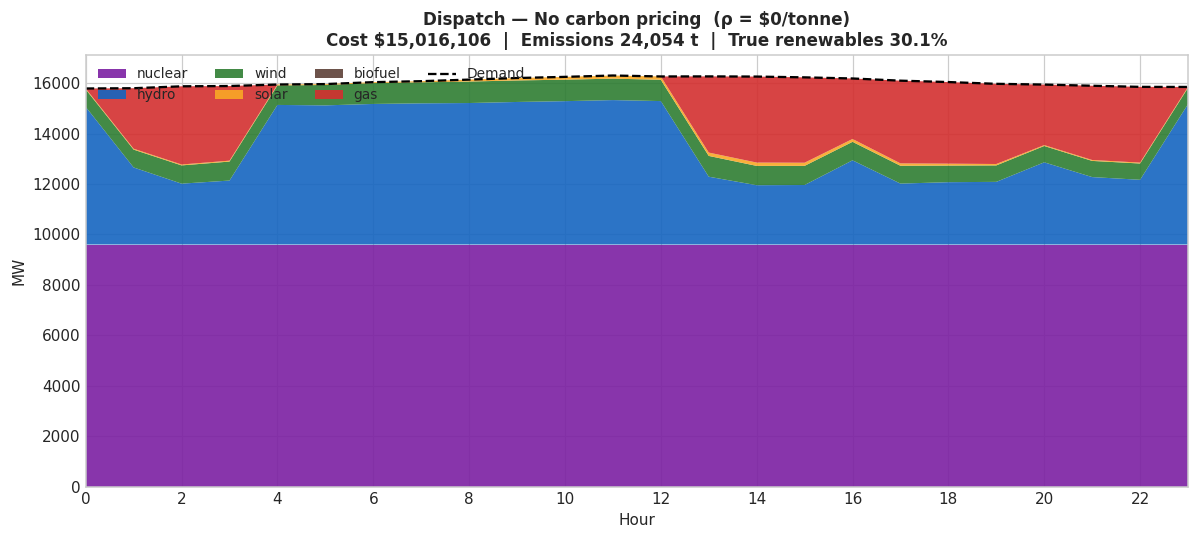

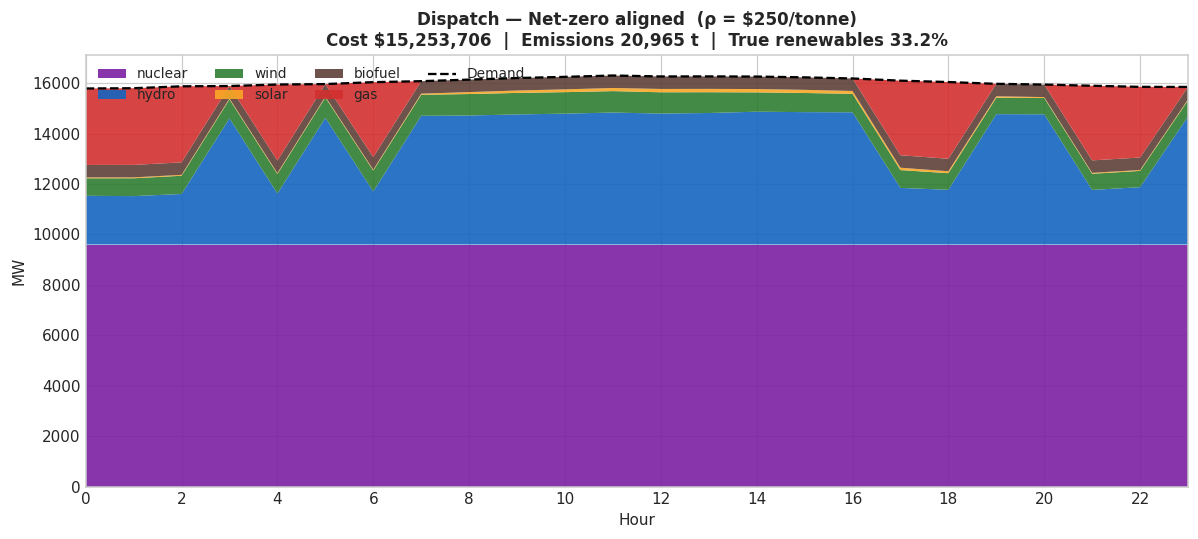

In [10]:
FUEL_COLORS = {
    'nuclear': '#7B1FA2', 'hydro':   '#1565C0',
    'gas':     '#D32F2F', 'wind':    '#2E7D32',
    'solar':   '#F9A825', 'biofuel': '#5D4037',
}
FUEL_ORDER = ['nuclear', 'hydro', 'wind', 'solar', 'biofuel', 'gas']


def plot_dispatch(dispatch_df, title):
    fig, ax = plt.subplots(figsize=(11, 5))
    ax.stackplot(
        dispatch_df.index,
        *[dispatch_df[f] for f in FUEL_ORDER],
        labels=FUEL_ORDER,
        colors=[FUEL_COLORS[f] for f in FUEL_ORDER],
        alpha=0.9,
    )
    ax.plot(dispatch_df.index, dispatch_df.sum(axis=1),
            'k--', lw=1.5, label='Demand')
    ax.set_xlabel('Hour')
    ax.set_ylabel('MW')
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_xticks(range(0, 24, 2))
    ax.set_xlim(0, 23)
    ax.legend(loc='upper left', ncol=4, fontsize=9)
    plt.tight_layout()
    return fig


for sname in ['No carbon pricing', 'Net-zero aligned']:
    if sname not in all_dispatch:
        print(f'  ⚠ {sname} not found — skipping')
        continue
    r   = next(row for row in results if row['Scenario'] == sname)
    fig = plot_dispatch(
        all_dispatch[sname],
        title=(f"Dispatch — {sname}  (ρ = ${r['rho ($/tonne CO2)']:.0f}/tonne)\n"
               f"Cost ${r['Cost (CAD)']:,.0f}  |  "
               f"Emissions {r['Emissions (t CO2)']:,.0f} t  |  "
               f"True renewables {r['Renewable (%)']:.1f}%")
    )
    fname = sname.replace(' ', '_').replace('/', '-')
    plt.savefig(OUT_DIR / f'fig_dispatch_{fname}.png', dpi=140, bbox_inches='tight')
    plt.show()

---
## Step 9 — Pareto Frontier: Cost vs Emissions

Each point is one carbon-price scenario. Moving left along the curve
means lower emissions at higher cost. The slope at each point is the
**Marginal Abatement Cost (MAC)** — $/tonne of CO₂ saved.

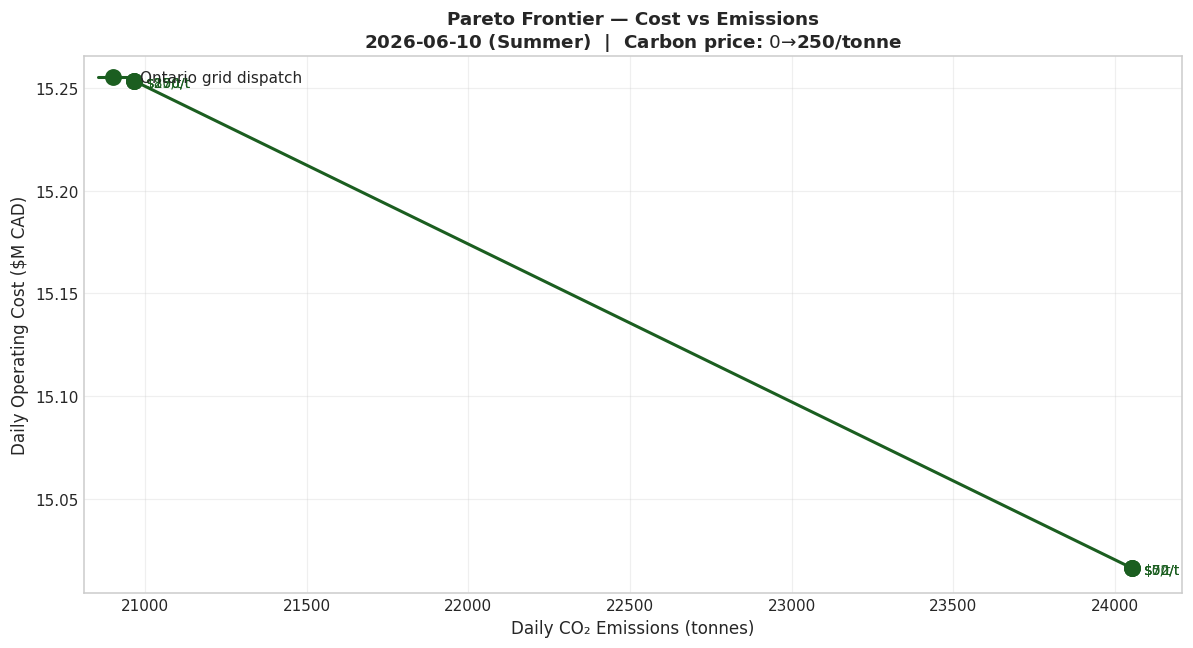


MARGINAL ABATEMENT COSTS
  How much extra cost to reduce emissions by 1 tonne?

  $ 250 → $  80/t  emissions unchanged (constraint-bound)
  $  80 → $ 170/t  emissions unchanged (constraint-bound)
  $ 170 → $   0/t  emissions unchanged (constraint-bound)
  $   0 → $  50/t  emissions unchanged (constraint-bound)
  $  50 → $  72/t  emissions unchanged (constraint-bound)


In [11]:
fig, ax = plt.subplots(figsize=(11, 6))

sub = results_df.sort_values('Emissions (t CO2)')

ax.plot(sub['Emissions (t CO2)'], sub['Cost (CAD)'] / 1e6,
        'o-', color='#1B5E20', lw=2, markersize=10, label='Ontario grid dispatch')

for _, row in sub.iterrows():
    ax.annotate(
        f"${row['rho ($/tonne CO2)']:.0f}/t",
        (row['Emissions (t CO2)'], row['Cost (CAD)'] / 1e6),
        textcoords='offset points', xytext=(8, -4),
        fontsize=9, color='#1B5E20',
    )

ax.set_xlabel('Daily CO₂ Emissions (tonnes)', fontsize=11)
ax.set_ylabel('Daily Operating Cost ($M CAD)', fontsize=11)
ax.set_title(
    f'Pareto Frontier — Cost vs Emissions\n'
    f'{TARGET_DATE} ({TARGET_SEASON.capitalize()})  |  '
    f'Carbon price: $0 → $250/tonne',
    fontweight='bold'
)
ax.legend(loc='upper left')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(OUT_DIR / 'fig_pareto.png', dpi=140, bbox_inches='tight')
plt.show()

# Marginal Abatement Cost
print('\nMARGINAL ABATEMENT COSTS')
print('  How much extra cost to reduce emissions by 1 tonne?\n')
prev = None
for _, row in sub.iterrows():
    if prev is not None:
        d_cost = row['Cost (CAD)'] - prev['Cost (CAD)']
        d_emit = prev['Emissions (t CO2)'] - row['Emissions (t CO2)']
        if d_emit > 0.1:
            mac = d_cost / d_emit
            print(f"  ${prev['rho ($/tonne CO2)']:>4.0f} → "
                  f"${row['rho ($/tonne CO2)']:>4.0f}/t  "
                  f"+${d_cost/1e6:.3f}M cost  "
                  f"−{d_emit:,.0f} t CO₂  "
                  f"MAC = ${mac:,.0f}/tCO₂")
        else:
            print(f"  ${prev['rho ($/tonne CO2)']:>4.0f} → "
                  f"${row['rho ($/tonne CO2)']:>4.0f}/t  "
                  f"emissions unchanged (constraint-bound)")
    prev = row

---
## Step 10 — Real-World Impact Analysis

Translates optimization results into numbers that mean something to
real people and policy makers:

- **Part A — Household cost calculator:** How much does each carbon price
  add to the average Ontario electricity bill per month?
- **Part B — Gas displacement & CO₂ avoided:** How much gas is avoided,
  how much CO₂ is saved, and what is the real-world equivalent?
- **Part C — Critical threshold:** What is the minimum carbon price for
  meaningful decarbonisation of Ontario's grid?

**Sources:**
- Ontario households: Statistics Canada 2024 (5.5M households)
- Average household usage: Ontario Energy Board Electricity Data 2024 (30 kWh/day)
- Tree CO₂ absorption: US Forest Service (21.7 kg CO₂/tree/year)
- Car CO₂: Natural Resources Canada 2024 (4,600 kg CO₂/car/year)

In [12]:
# ── Constants ─────────────────────────────────────────────────────────────────
ONTARIO_HOUSEHOLDS    = 5_500_000
AVG_HOUSEHOLD_KWH_DAY = 30          # kWh/day
TREE_CO2_KG_PER_YEAR  = 21.7        # kg CO2/tree/year
CAR_CO2_KG_PER_YEAR   = 4_600       # kg CO2/car/year

# ── Baseline (no carbon price) ────────────────────────────────────────────────
baseline_row      = results_df[results_df['rho ($/tonne CO2)'] == 0.0].iloc[0]
baseline_gas_mwh  = all_dispatch[baseline_row['Scenario']]['gas'].sum()
baseline_cost     = baseline_row['Cost (CAD)']
daily_demand_mwh  = demand_forecast.sum()
baseline_cost_mwh = baseline_cost / daily_demand_mwh

print('=' * 72)
print('  OMEGA — REAL-WORLD IMPACT ANALYSIS')
print(f'  Date   : {TARGET_DATE}  |  Season: {TARGET_SEASON.capitalize()}')
print(f'  Demand : {daily_demand_mwh:,.0f} MWh/day  '
      f'(peak {demand_forecast.max():,.0f} MW)')
print(f'  Baseline gas dispatch: {baseline_gas_mwh:,.0f} MWh/day at $0/tonne')
print('=' * 72)


# ── PART A: Household Cost Calculator ─────────────────────────────────────────
print('\n  PART A — What Does Carbon Pricing Cost the Average Household?\n')
print(f'  {"Scenario":<32} {"ρ":>6}  {"$/MWh":>8}  '
      f'{"Extra/MWh":>10}  {"$/month HH":>11}')
print(f'  {"─" * 72}')

for _, row in results_df.iterrows():
    cost_mwh       = row['Cost (CAD)'] / daily_demand_mwh
    extra_mwh      = cost_mwh - baseline_cost_mwh
    hh_monthly     = extra_mwh * AVG_HOUSEHOLD_KWH_DAY / 1000 * 30

    print(f"  {row['Scenario']:<32} "
          f"${row['rho ($/tonne CO2)']:>4.0f}/t  "
          f"${cost_mwh:>7.2f}/MWh  "
          f"+${extra_mwh:>7.4f}/MWh  "
          f"+${hh_monthly:>8.2f}/mo")

# Summary line
top_row      = results_df.sort_values('rho ($/tonne CO2)').iloc[-1]
top_extra_mwh = top_row['Cost (CAD)'] / daily_demand_mwh - baseline_cost_mwh
top_hh_mo    = top_extra_mwh * AVG_HOUSEHOLD_KWH_DAY / 1000 * 30
print(f'\n  → At ${top_row["rho ($/tonne CO2)"]:.0f}/tonne, the average '
      f'Ontario household pays an extra '
      f'${top_hh_mo:.2f}/month on electricity.')


# ── PART B: Gas Displacement & CO2 Avoided ────────────────────────────────────
print('\n\n  PART B — Gas Displaced and CO₂ Avoided vs $0/tonne Baseline\n')
print(f'  {"Scenario":<32} {"Gas (MWh)":>10}  {"Displaced":>10}  '
      f'{"CO₂ saved (t)":>14}  {"≈ Trees":>10}  {"≈ Cars off":>10}')
print(f'  {"─" * 92}')

for _, row in results_df.iterrows():
    dispatch       = all_dispatch[row['Scenario']]
    gas_mwh        = dispatch['gas'].sum()
    displaced_mwh  = baseline_gas_mwh - gas_mwh
    co2_avoided_kg = displaced_mwh * FUELS['gas']['emit']
    co2_avoided_t  = co2_avoided_kg / 1000
    trees_equiv    = co2_avoided_kg / TREE_CO2_KG_PER_YEAR
    cars_equiv     = co2_avoided_kg / CAR_CO2_KG_PER_YEAR

    print(f"  {row['Scenario']:<32} "
          f"{gas_mwh:>10,.0f}  "
          f"{displaced_mwh:>+10,.0f}  "
          f"{co2_avoided_t:>14,.1f}  "
          f"{trees_equiv:>10,.0f}  "
          f"{cars_equiv:>10,.1f}")


# ── PART C: Critical Threshold ────────────────────────────────────────────────
print('\n\n  PART C — Critical Carbon Price Threshold\n')

threshold_50 = None
threshold_75 = None

for _, row in results_df.sort_values('rho ($/tonne CO2)').iterrows():
    if baseline_gas_mwh == 0:
        break
    gas_ratio = all_dispatch[row['Scenario']]['gas'].sum() / baseline_gas_mwh
    if gas_ratio <= 0.50 and threshold_50 is None:
        threshold_50 = row['rho ($/tonne CO2)']
    if gas_ratio <= 0.25 and threshold_75 is None:
        threshold_75 = row['rho ($/tonne CO2)']

if baseline_gas_mwh < 500:
    print('  Ontario\'s grid is already highly decarbonised at nominal demand.')
    print(f'  Gas dispatch at $0/tonne: only {baseline_gas_mwh:,.0f} MWh — '
          f'nuclear + renewables cover the day.')
elif threshold_50:
    print(f'  50% gas displacement reached at : ${threshold_50:.0f}/tonne')
    if threshold_75:
        print(f'  75% gas displacement reached at : ${threshold_75:.0f}/tonne')
    else:
        print('  75% gas displacement : not reached within $0–$250/tonne range')
    print(f'\n  → ${ threshold_50:.0f}/tonne is the minimum carbon price for meaningful')
    print(f'    decarbonisation of Ontario\'s {TARGET_SEASON} electricity grid.')
else:
    print('  50% gas displacement not reached within $0–$250/tonne.')
    print('  Gas plays a limited role even without carbon pricing on this date.')


# ── SUMMARY FOR REPORT ────────────────────────────────────────────────────────
top_gas      = all_dispatch[top_row['Scenario']]['gas'].sum()
top_co2_save = (baseline_gas_mwh - top_gas) * FUELS['gas']['emit'] / 1000

print(f'\n  {"─" * 72}')
print(f'  SUMMARY FOR REPORT')
print(f'  {"─" * 72}')
print(f'  On {TARGET_DATE} ({TARGET_SEASON}), Ontario dispatched '
      f'{baseline_gas_mwh:,.0f} MWh of gas')
print(f'  at $0/tonne carbon price.')
print(f'  At ${top_row["rho ($/tonne CO2)"]:.0f}/tonne (net-zero aligned):')
print(f'    • Gas drops to {top_gas:,.0f} MWh '
      f'(−{baseline_gas_mwh - top_gas:,.0f} MWh, '
      f'−{(baseline_gas_mwh - top_gas)/max(baseline_gas_mwh,1)*100:.0f}%)')
print(f'    • CO₂ avoided   : {top_co2_save:,.0f} tonnes/day')
print(f'    • Tree equivalent: {top_co2_save*1000/TREE_CO2_KG_PER_YEAR:,.0f} trees/year')
print(f'    • Household cost : +${top_hh_mo:.2f}/month per Ontario household')
if threshold_50:
    print(f'    • Critical threshold: ${threshold_50:.0f}/tonne for 50% gas displacement')
print(f'  {"─" * 72}')

  OMEGA — REAL-WORLD IMPACT ANALYSIS
  Date   : 2026-06-10  |  Season: Summer
  Demand : 385,198 MWh/day  (peak 16,305 MW)
  Baseline gas dispatch: 38,730 MWh/day at $0/tonne

  PART A — What Does Carbon Pricing Cost the Average Household?

  Scenario                              ρ     $/MWh   Extra/MWh   $/month HH
  ────────────────────────────────────────────────────────────────────────
  No carbon pricing                $   0/t  $  38.98/MWh  +$ 0.0000/MWh  +$    0.00/mo
  Light industrial pricing         $  50/t  $  38.98/MWh  +$ 0.0000/MWh  +$    0.00/mo
  Ontario EPS 2025                 $  72/t  $  38.98/MWh  +$ 0.0000/MWh  +$    0.00/mo
  Federal industrial 2024          $  80/t  $  39.60/MWh  +$ 0.6168/MWh  +$    0.56/mo
  Federal industrial 2030          $ 170/t  $  39.60/MWh  +$ 0.6168/MWh  +$    0.56/mo
  Net-zero aligned                 $ 250/t  $  39.60/MWh  +$ 0.6168/MWh  +$    0.56/mo

  → At $250/tonne, the average Ontario household pays an extra $0.56/month on electr